
SIMULATION LOG (HARD WALL POTENTIAL)
Running L= 1.0 | N=  60 ... 

<>:268: SyntaxWarning: invalid escape sequence '\m'
<>:269: SyntaxWarning: invalid escape sequence '\s'
<>:270: SyntaxWarning: invalid escape sequence '\m'
<>:278: SyntaxWarning: invalid escape sequence '\m'
<>:279: SyntaxWarning: invalid escape sequence '\s'
<>:280: SyntaxWarning: invalid escape sequence '\m'
<>:268: SyntaxWarning: invalid escape sequence '\m'
<>:269: SyntaxWarning: invalid escape sequence '\s'
<>:270: SyntaxWarning: invalid escape sequence '\m'
<>:278: SyntaxWarning: invalid escape sequence '\m'
<>:279: SyntaxWarning: invalid escape sequence '\s'
<>:280: SyntaxWarning: invalid escape sequence '\m'
C:\Users\pierd\AppData\Local\Temp\ipykernel_1820\2491404436.py:268: SyntaxWarning: invalid escape sequence '\m'
  plt.errorbar(Ls, Mus, yerr=Errs, fmt='o-', capsize=5, ecolor='red', color='blue', label='Excess $\mu$')
C:\Users\pierd\AppData\Local\Temp\ipykernel_1820\2491404436.py:269: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Pore Width $L$ ($\sigma$)")
C:\U

Done (2.66s)
Running L= 2.0 | N= 120 ... Done (1.09s)
Running L= 5.0 | N= 300 ... Done (2.48s)
Running L=10.0 | N= 600 ... Done (3.87s)


 FINAL RESULTS TABLE (HARD WALLS) 
L     | Mu_Excess       | Mu_Total        | Error (+/-)    
--------------------------------------------------------------------------------
1.0   | 1.6265          | 0.6049          | 0.0358         
2.0   | 1.4970          | 0.4753          | 0.0216         
5.0   | 1.4873          | 0.4657          | 0.0277         
10.0  | 1.4328          | 0.4112          | 0.0305         


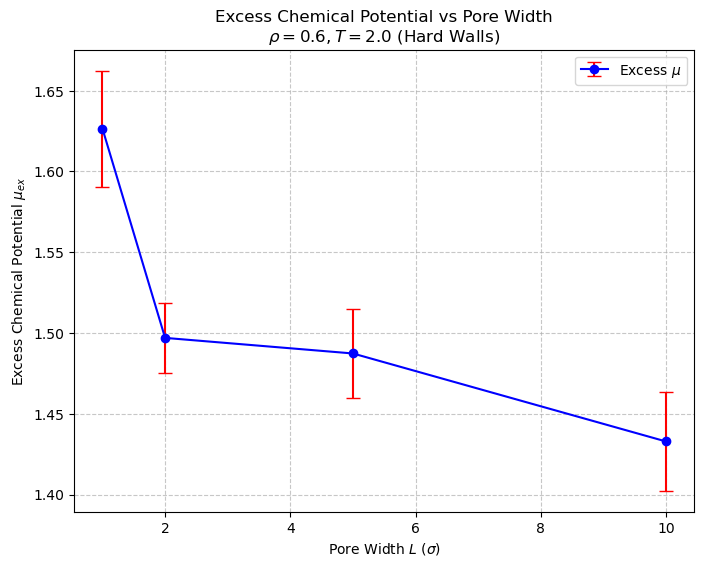

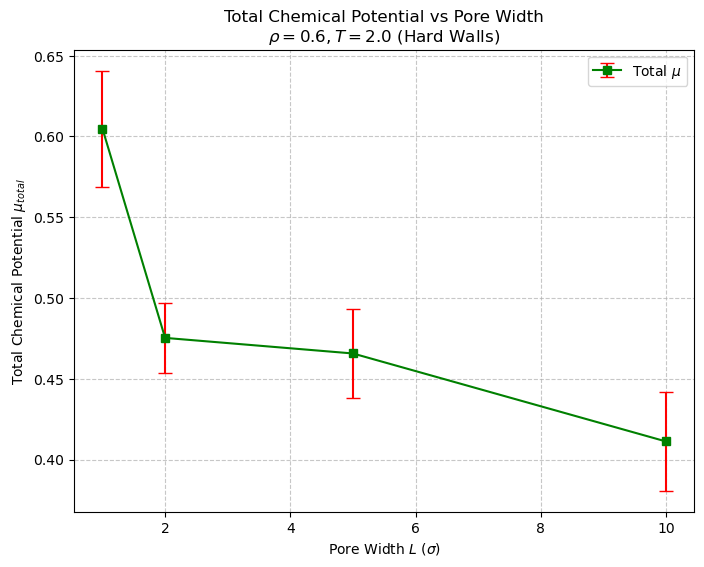

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit

# --- 1. Constants & Parameters ---
# Lennard-Jones Parameters (Reduced units)
EPSILON = 1.0
SIGMA = 1.0
RCUT = 2.5
RCUT_SQ = RCUT**2

# Simulation Settings
TEMP = 2.0
TARGET_RHO = 0.6
MC_STEPS = 50000        # Production steps
EQUIL_STEPS = 10000     # Equilibration steps
WIDOM_FREQ = 10         # Sample Widom every N steps
NUM_TEST_PARTICLES = 200 # Number of ghost insertions per sample

# Error Analysis Settings
N_BLOCKS = 5            # Number of blocks for error estimation

# --- 2. JIT-Compiled Potential Functions ---

@njit(fastmath=True)
def lj_pair_energy(r2):
    """Calculates LJ energy for squared distance r2."""
    if r2 > RCUT_SQ:
        return 0.0
    
    ir2 = 1.0 / r2
    ir6 = ir2 * ir2 * ir2
    ir12 = ir6 * ir6
    
    u = 4.0 * EPSILON * (ir12 - ir6)
    
    # Shifted potential (Energy at cutoff)
    rc2_inv = 1.0 / RCUT_SQ
    rc6_inv = rc2_inv * rc2_inv * rc2_inv
    rc12_inv = rc6_inv * rc6_inv
    u_cut = 4.0 * EPSILON * (rc12_inv - rc6_inv)
    
    return u - u_cut

@njit(fastmath=True)
def hard_wall_potential(z, L_z):
    """
    Hard Wall Potential.
    U(z) = 0      if 0 < z < L
    U(z) = inf    otherwise
    """
    if z <= 0.0 or z >= L_z:
        return 1e10 # Infinite energy (Collision)
    else:
        return 0.0  # Zero energy inside the pore

@njit(fastmath=True)
def compute_energy_delta(idx_move, new_pos, coords, n_particles, box_L, L_z):
    """
    Computes energy change.
    For Hard Walls: If outside, return Inf. If inside, Wall Energy is 0.
    """
    
    # 1. Hard Wall Check
    # We check new position immediately. If outside, return infinite energy.
    u_wall_new = hard_wall_potential(new_pos[2], L_z)
    if u_wall_new > 1e9: 
        return 1e10
    
    # 2. Pair Interaction
    delta_pair = 0.0
    
    for i in range(n_particles):
        if i == idx_move: continue
            
        dx = new_pos[0] - coords[i, 0]
        dy = new_pos[1] - coords[i, 1]
        dz = new_pos[2] - coords[i, 2]
        
        # PBC (X, Y only)
        dx -= box_L * round(dx / box_L)
        dy -= box_L * round(dy / box_L)
        
        r2_new = dx*dx + dy*dy + dz*dz
        delta_pair += lj_pair_energy(r2_new)
        
        # Subtract old energy (if not insertion)
        if idx_move != -1:
            dx_o = coords[idx_move, 0] - coords[i, 0]
            dy_o = coords[idx_move, 1] - coords[i, 1]
            dz_o = coords[idx_move, 2] - coords[i, 2]
            
            dx_o -= box_L * round(dx_o / box_L)
            dy_o -= box_L * round(dy_o / box_L)
            
            r2_old = dx_o*dx_o + dy_o*dy_o + dz_o*dz_o
            delta_pair -= lj_pair_energy(r2_old)
            
    return delta_pair # Wall part is zero if accepted

# --- 3. Core Loop with Block Averaging (Compiled) ---

@njit
def run_mc_simulation(coords, n_particles, L_box, L_z, temp, mc_steps, equil_steps, widom_freq, n_test, n_blocks):
    """
    Runs MC loop and computes Widom factor with Block Averaging error.
    """
    beta = 1.0 / temp
    
    steps_per_block = mc_steps // n_blocks
    block_widom_accum = np.zeros(n_blocks)
    block_counts = np.zeros(n_blocks)
    
    total_steps = mc_steps + equil_steps
    
    for step in range(total_steps):
        
        # --- A. Particle Displacement ---
        idx = np.random.randint(n_particles)
        old_pos = coords[idx].copy()
        
        disp = (np.random.rand(3) - 0.5) * 1.0 
        new_pos = np.empty(3)
        new_pos[0] = old_pos[0] + disp[0]
        new_pos[1] = old_pos[1] + disp[1]
        new_pos[2] = old_pos[2] + disp[2]
        
        # PBC X/Y
        new_pos[0] = new_pos[0] % L_box
        new_pos[1] = new_pos[1] % L_box
        
        dE = compute_energy_delta(idx, new_pos, coords, n_particles, L_box, L_z)
        
        if dE < 1e9:
            if dE < 0 or np.random.rand() < np.exp(-beta * dE):
                coords[idx] = new_pos 
                
        # --- B. Widom Insertion (Production Phase Only) ---
        if step >= equil_steps and step % widom_freq == 0:
            
            prod_step = step - equil_steps
            block_idx = prod_step // steps_per_block
            if block_idx >= n_blocks: block_idx = n_blocks - 1
            
            current_sample_avg = 0.0
            for _ in range(n_test):
                ghost_pos = np.empty(3)
                ghost_pos[0] = np.random.rand() * L_box
                ghost_pos[1] = np.random.rand() * L_box
                ghost_pos[2] = np.random.rand() * L_z # Random Z anywhere in box
                
                u_test = compute_energy_delta(-1, ghost_pos, coords, n_particles, L_box, L_z)
                
                if u_test < 1e9:
                    current_sample_avg += np.exp(-beta * u_test)
            
            block_widom_accum[block_idx] += (current_sample_avg / n_test)
            block_counts[block_idx] += 1

    # --- C. Post-Run Analysis ---
    
    block_averages = np.zeros(n_blocks)
    for i in range(n_blocks):
        if block_counts[i] > 0:
            block_averages[i] = block_widom_accum[i] / block_counts[i]
        else:
            block_averages[i] = 0.0
            
    global_widom = 0.0
    valid_blocks = 0
    for i in range(n_blocks):
        if block_averages[i] > 0:
            global_widom += block_averages[i]
            valid_blocks += 1
            
    if valid_blocks > 0:
        global_widom /= valid_blocks
    else:
        return 0.0, 0.0 
    
    variance = 0.0
    for i in range(n_blocks):
        variance += (block_averages[i] - global_widom)**2
        
    std_dev = np.sqrt(variance / (valid_blocks - 1)) if valid_blocks > 1 else 0.0
    widom_error = std_dev / np.sqrt(valid_blocks)
    
    return global_widom, widom_error

# --- 4. Main Driver ---

def run_system(L_pore_val):
    L_box = 10.0
    vol = L_box * L_box * L_pore_val
    n_particles = int(TARGET_RHO * vol)
    
    print(f"Running L={L_pore_val:4.1f} | N={n_particles:4d} ... ", end="", flush=True)
    
    # Init Config
    coords = np.zeros((n_particles, 3))
    coords[:, 0] = np.random.uniform(0, L_box, n_particles)
    coords[:, 1] = np.random.uniform(0, L_box, n_particles)
    coords[:, 2] = np.random.uniform(0.1, L_pore_val - 0.1, n_particles)
    
    start_t = time.time()
    
    # Run Compiled Simulation
    avg_widom, err_widom = run_mc_simulation(
        coords, n_particles, L_box, L_pore_val, TEMP, 
        MC_STEPS, EQUIL_STEPS, WIDOM_FREQ, NUM_TEST_PARTICLES, N_BLOCKS
    )
    
    end_t = time.time()
    print(f"Done ({end_t - start_t:.2f}s)")
    
    # Calculate Chemical Potentials
    if avg_widom < 1e-12:
        return np.inf, 0.0, np.inf
    
    mu_ex = -TEMP * np.log(avg_widom)
    mu_ex_err = TEMP * (err_widom / avg_widom)
    
    mu_id = TEMP * np.log(TARGET_RHO)
    mu_tot = mu_ex + mu_id
    
    return mu_ex, mu_ex_err, mu_tot

# --- 5. Execution & Report Output ---

distances = [1.0, 2.0, 5.0, 10.0]
results = []

print("\n" + "="*80)
print(f"SIMULATION LOG (HARD WALL POTENTIAL)")
print("="*80)

for L in distances:
    m_ex, m_err, m_tot = run_system(L)
    results.append((L, m_ex, m_err, m_tot))

# --- REPORT DATA SECTION ---
print("\n\n" + "="*80)
print(" FINAL RESULTS TABLE (HARD WALLS) ")
print("="*80)
print(f"{'L':<5} | {'Mu_Excess':<15} | {'Mu_Total':<15} | {'Error (+/-)':<15}")
print("-" * 80)

for r in results:
    L, mu_ex, mu_err, mu_tot = r
    if mu_ex == np.inf:
        print(f"{L:<5.1f} | {'Infinity':<15} | {'Infinity':<15} | {'---':<15}")
    else:
        print(f"{L:<5.1f} | {mu_ex:<15.4f} | {mu_tot:<15.4f} | {mu_err:<15.4f}")

print("="*80)

# --- PLOTTING ---

Ls = [r[0] for r in results if r[1] != np.inf]
Mus = [r[1] for r in results if r[1] != np.inf] # Excess
Errs = [r[2] for r in results if r[1] != np.inf] # Error (Same for both)
Mut = [r[3] for r in results if r[1] != np.inf] # Total

if len(Ls) > 0:
    # Plot 1: Excess Chemical Potential
    plt.figure(figsize=(8, 6))
    plt.errorbar(Ls, Mus, yerr=Errs, fmt='o-', capsize=5, ecolor='red', color='blue', label='Excess $\mu$')
    plt.xlabel("Pore Width $L$ ($\sigma$)")
    plt.ylabel("Excess Chemical Potential $\mu_{ex}$")
    plt.title(f"Excess Chemical Potential vs Pore Width\n$\\rho={TARGET_RHO}, T={TEMP}$ (Hard Walls)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

    # Plot 2: Total Chemical Potential
    plt.figure(figsize=(8, 6))
    plt.errorbar(Ls, Mut, yerr=Errs, fmt='s-', capsize=5, ecolor='red', color='green', label='Total $\mu$')
    plt.xlabel("Pore Width $L$ ($\sigma$)")
    plt.ylabel("Total Chemical Potential $\mu_{total}$")
    plt.title(f"Total Chemical Potential vs Pore Width\n$\\rho={TARGET_RHO}, T={TEMP}$ (Hard Walls)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()